<h2> Лабораторна робота №2 “Пошук асоціативних правил” </h2>

<h3>1. Завантаження та підготовка даних</h3>
<ol>
    <li>Викачати архів ml-latest-small.zip і розпакувати.</li>
    <li>Завантажити таблиці ratings.csv і movies.csv за допомогою pandas.</li>
    <li>Виконати об’єднання таблиць за полем movieId.</li>
    <li>Для подальшого аналізу вибрати лише користувацькі оцінки rating ≥ 4.0, вважаючи, що це “фільми що сподобались користувачам”.</li>
    <li>Вивести розміри таблиць та кількість унікальних користувачів і фільмів.</li>

</ol>

In [2]:
import pandas as pd
import zipfile
import urllib.request
import os
from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
url = "https://files.grouplens.org/datasets/movielens/ml-latest-small.zip"
zip_path = "ml-latest-small.zip"

if not os.path.exists(zip_path):
    print("Loading archive...")
    urllib.request.urlretrieve(url, zip_path)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("data")
    print("Archive was unziped in folder 'data'")

ratings = pd.read_csv("data/ml-latest-small/ratings.csv")
movies = pd.read_csv("data/ml-latest-small/movies.csv")

data = pd.merge(ratings, movies, on='movieId')

liked_movies = data[data['rating'] >= 4.0].copy()

print("-" * 30)
print(f"Size of the initial table (all estimates): {data.shape}")
print(f"Filtered table size (rating >= 4.0): {liked_movies.shape}")
print(f"Number of unique users: {liked_movies['userId'].nunique()}")
print(f"Number of unique movies (with high rate): {liked_movies['title'].nunique()}")

liked_movies.head()

Archive was unziped in folder 'data'
------------------------------
Size of the initial table (all estimates): (100836, 6)
Filtered table size (rating >= 4.0): (48580, 6)
Number of unique users: 609
Number of unique movies (with high rate): 6297


,userId,movieId,rating,timestamp,title,genres
0,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,1,3,4.0,964981247,Grumpier Old Men (1995),Comedy|Romance
2,1,6,4.0,964982224,Heat (1995),Action|Crime|Thriller
3,1,47,5.0,964983815,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,1,50,5.0,964982931,"Usual Suspects, The (1995)",Crime|Mystery|Thriller


<h3>2. Перетворення даних у транзакційний формат</h3>
<ol>
    <li>Створити матрицю (або DataFrame) у форматі:
         рядки — користувачі (userId),
         стовпці — фільми (title),
         значення — 1, якщо користувач поставив оцінку ≥ 4.0, і 0 інакше.
    </li>
    <li>Вивести кілька перших рядків матриці для перевірки.</li>
</ol>

In [4]:
basket = (liked_movies
          .groupby(['userId', 'title'])['rating']
          .count().unstack().reset_index()
          .fillna(0)
          .set_index('userId'))

def encode_units(x):
    if x <= 0:
        return 0
    if x >= 1:
        return 1

basket_sets = basket.map(encode_units).astype(bool)

print(f"Size of array: {basket_sets.shape}")
basket_sets.head()

Size of array: (609, 6297)


title,'71 (2014),'Hellboy': The Seeds of Creation (2004),'Salem's Lot (2004),'Til There Was You (1997),"'burbs, The (1989)",(500) Days of Summer (2009),*batteries not included (1987),...And Justice for All (1979),00 Schneider - Jagd auf Nihil Baxter (1994),1-900 (06) (1994),...,Zombieland (2009),Zookeeper (2011),Zoolander (2001),Zootopia (2016),Zulu (1964),[REC] (2007),[REC]² (2009),eXistenZ (1999),xXx (2002),¡Three Amigos! (1986)
userId,,,,,,,,,,,,,,,,,,,,,
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
5,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


<h3>3. Пошук частих наборів фільмів</h3>
<ol>
    <li>Використати алгоритм Apriori для пошуку частих наборів елементів.</li>
    <li>Вивести кількість знайдених частих наборів при різних порогах min_support (наприклад, 0.05, 0.1, 0.3).</li>
    <li>Відсортувати результати за значенням support і вивести топ-10 найпопулярніших комбінацій фільмів.</li>
    <li>Інтерпретувати, які фільми часто зустрічаються разом у вподобаннях користувачів.</li>
</ol>

In [5]:
thresholds = [0.05, 0.1, 0.3]
results = {}

print("Frequent dialing search results:")
print("-" * 40)

for ts in thresholds:
    f_itemsets = apriori(basket_sets, min_support=ts, use_colnames=True)
    results[ts] = len(f_itemsets)
    print(f"With min_support = {ts:4}: found {len(f_itemsets):5} sets")

frequent_itemsets = apriori(basket_sets, min_support=0.05, use_colnames=True)

top_10_itemsets = frequent_itemsets.sort_values(by='support', ascending=False).head(10)

print("\nTop 10 most popular movie combinations (highest support):")
display(top_10_itemsets)


frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(lambda x: len(x))

print("\nMost popular movie PAIRS (shared preferences):")
pairs = frequent_itemsets[frequent_itemsets['length'] >= 2].sort_values(by='support', ascending=False).head(5)
display(pairs)

Frequent dialing search results:
----------------------------------------
With min_support = 0.05: found 33189 sets
With min_support =  0.1: found   863 sets
With min_support =  0.3: found     6 sets

Top 10 most popular movie combinations (highest support):


,support,itemsets
267,0.449918,"frozenset({Shawshank Redemption, The (1994)})"
119,0.408867,frozenset({Forrest Gump (1994)})
244,0.400657,frozenset({Pulp Fiction (1994)})
273,0.369458,"frozenset({Silence of the Lambs, The (1991)})"
206,0.364532,"frozenset({Matrix, The (1999)})"
299,0.330049,frozenset({Star Wars: Episode IV - A New Hope ...
115,0.293924,frozenset({Fight Club (1999)})
260,0.287356,frozenset({Schindler's List (1993)})
2228,0.275862,"frozenset({Forrest Gump (1994), Shawshank Rede..."
300,0.275862,frozenset({Star Wars: Episode V - The Empire S...



Most popular movie PAIRS (shared preferences):


,support,itemsets,length
2228,0.275862,"frozenset({Forrest Gump (1994), Shawshank Rede...",2
3607,0.259442,"frozenset({Pulp Fiction (1994), Shawshank Rede...",2
3610,0.249589,"frozenset({Pulp Fiction (1994), Silence of the...",2
3965,0.236453,frozenset({Star Wars: Episode IV - A New Hope ...,2
3823,0.229885,"frozenset({Silence of the Lambs, The (1991), S...",2


<h3>4. Побудова асоціативних правил</h3>
<ol>
    <li>Побудувати асоціативні правила.</li>
    <li>Додати обчислення метрик support, confidence, lift.</li>
    <li>Відсортувати та вивести топ-10 правил за lift.</li>
    <li>Інтерпретувати кілька правил.</li>
    <li>Візуалізувати розподіл метрик (графіки support–confidence, lift–confidence тощо).</li>
</ol>

Association Rules:
Minimum confidence: 0.9
Number of rules: 18533

Top 10 rules by indicator Lift:


,rule,support,confidence,lift
17680,"Star Wars: Episode IV - A New Hope (1977), Kil...",0.052545,0.969697,12.837945
17677,"Star Wars: Episode IV - A New Hope (1977), Sta...",0.052545,0.941176,12.737255
17681,Star Wars: Episode VI - Return of the Jedi (19...,0.052545,0.914286,12.654545
13454,"Star Wars: Episode IV - A New Hope (1977), Kil...",0.057471,0.945946,12.523502
13438,"Kill Bill: Vol. 2 (2004), Star Wars: Episode V...",0.055829,0.944444,12.503623
13452,"Star Wars: Episode IV - A New Hope (1977), Sta...",0.057471,0.921053,12.464912
13437,Star Wars: Episode VI - Return of the Jedi (19...,0.055829,0.918919,12.436036
5715,Star Wars: Episode VI - Return of the Jedi (19...,0.060755,0.902439,12.213008
13428,"Star Wars: Episode IV - A New Hope (1977), Kil...",0.057471,0.921053,12.193936
13446,"Kill Bill: Vol. 2 (2004), Star Wars: Episode V...",0.052545,0.914286,12.104348



Rule Quality Analysis:
Average confidence: 0.948
Average lift: 3.264
Rules with lift > 1: 18533


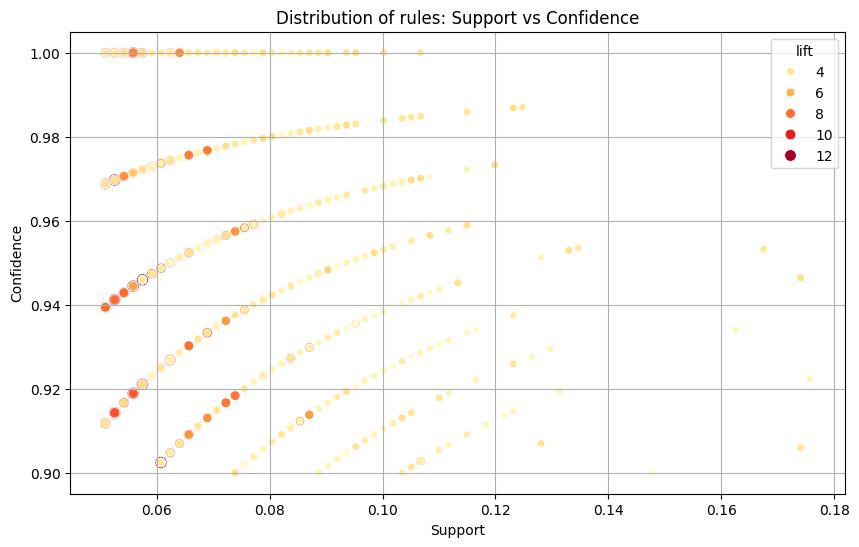

In [6]:
min_confidence = 0.9
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=min_confidence)

print("Association Rules:")
print(f"Minimum confidence: {min_confidence}")
print(f"Number of rules: {len(rules)}")

if len(rules) > 0:
    rules_display = rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].copy()
    
    rules_display['rule'] = rules_display['antecedents'].apply(lambda x: ', '.join(list(x))) + \
                            ' → ' + \
                            rules_display['consequents'].apply(lambda x: ', '.join(list(x)))
    
    top_10_rules = rules_display.sort_values(by='lift', ascending=False).head(10)
    
    print(f"\nTop 10 rules by indicator Lift:")
    display(top_10_rules[['rule', 'support', 'confidence', 'lift']])

    print(f"\nRule Quality Analysis:")
    print(f"Average confidence: {rules['confidence'].mean():.3f}")
    print(f"Average lift: {rules['lift'].mean():.3f}")
    print(f"Rules with lift > 1: {len(rules[rules['lift'] > 1])}")

    plt.figure(figsize=(10, 6))
    sns.scatterplot(x="support", y="confidence", size="lift", hue="lift", 
                    data=rules, palette="YlOrRd")
    plt.title("Distribution of rules: Support vs Confidence")
    plt.xlabel("Support")
    plt.ylabel("Confidence")
    plt.grid(True)
    plt.show()

else:
    print("No rules with this confidence threshold were found. Try reducing min_confidence..")

<h3>5. Аналіз та висновки</h3>
<ol>
    <li>Зробити висновки щодо того, як асоціативні правила можна застосувати у системах рекомендацій.</li>
    <li>Оцінити вплив параметрів min_support і min_confidence на кількість і якість знайдених правил.</li>
</ol>

Отримані правила можуть бути безпосередньо інтегровані у функціонал стрімінгових сервісів. Завдяки високому показнику confidence, система може з точністю понад 90% пропонувати фільм-наслідок (consequent), якщо користувач вподобав фільм-умову (antecedent). Використання метрики lift дозволяє виявити нетривіальні зв’язки, які не базуються лише на загальній популярності контенту, що робить рекомендації більш персоналізованими та корисними для утримання користувачів.
    

Експерименти з параметрами показали критичну залежність якості моделі від встановлених порогів:

min_support: Високий поріг (0.3) виявився надто жорстким, залишивши лише 6 найпопулярніших наборів, що недостатньо для побудови бази знань. Зниження порогу до 0.05 дозволило знайти 33 189 наборів, забезпечивши широке охоплення асоціацій.

min_confidence: Встановлення порогу на рівні 0.9 гарантує виняткову надійність кожної окремої рекомендації. Однак для систем, де важливо пропонувати велику кількість різноманітних варіантів, цей поріг доцільно знижувати до 0.6–0.7, щоб збалансувати точність та обсяг видачі.

Таким чином, розроблена модель на базі алгоритму Apriori демонструє високу здатність до виявлення прихованих закономірностей у поведінці користувачів, що є ключовим для побудови інтелектуальних систем підтримки прийняття рішень у сфері медіа-контенту.